In [1]:
import os

import pandas as pd
from tqdm import tqdm

tqdm.pandas()

# 1. Load raw data and convert to training data

In [21]:
import gzip
import json

from tqdm import tqdm

FILE_PATHS = [
    '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_2/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_3/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_4/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_5/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/gpt-4.1_maxiter_100_N_v0.61.0-no-hint-train-eval_swebench-verified_gpt-4_1-t05-run_1/output.with_completions.jsonl.gz',
]

# More memory efficient for large files
# Initialize lists to store the data
data = []


# Read file line by line
for FILE_PATH in FILE_PATHS:
    with gzip.open(FILE_PATH, 'rb') as f:  # Use 'rb' for gzipped files
        for i, line in tqdm(
            enumerate(f), desc=f'Processing {FILE_PATH.split("/")[-1]}'
        ):
            # Parse only the fields we need
            raw_data = json.loads(line)
            data.append(
                {
                    'resolved': raw_data['report']['resolved'],
                    'messages': raw_data['raw_completions']['messages']
                    if raw_data['raw_completions'] is not None
                    else None,
                    'git_patch': raw_data['test_result'].get('git_patch', ''),
                    'tools': raw_data['raw_completions']['tools']
                    if raw_data['raw_completions'] is not None
                    and 'tools' in raw_data['raw_completions']
                    else None,
                }
            )

# Convert to DataFrame after collecting all data
df = pd.DataFrame(data)
print(f'#total amount of data={len(df)}')
df = df[~df['messages'].isna()]
print(f'#total amount of data after removing nan={len(df)}')

Processing output.with_completions.jsonl.gz: 2119it [00:16, 131.06it/s]

#total amount of data=2119
#total amount of data after removing nan=2092


## Filter

In [22]:
def _contains_multiple_tool_calls(messages: list[dict]) -> bool:
    return any(
        message.get('tool_calls') and len(message['tool_calls']) > 1
        for message in messages
    )


df['contains_multiple_tool_calls'] = df['messages'].apply(_contains_multiple_tool_calls)
display(df.groupby(['contains_multiple_tool_calls'])['resolved'].sum())

contains_multiple_tool_calls
False    634
Name: resolved, dtype: int64

In [23]:
import copy

# Convert function calling messages to non-function calling messages
from openhands.llm.fn_call_converter import (
    FunctionCallConversionError,
    convert_fncall_messages_to_non_fncall_messages,
    convert_from_multiple_tool_calls_to_single_tool_call_messages,
)

total_failed = 0


def _convert_messages(messages: list[dict], tools: list[dict]) -> list[dict]:
    global total_failed
    message_copy = copy.deepcopy(messages)
    for message in message_copy:
        if message['content'] is None:
            message['content'] = ''
    try:
        return convert_fncall_messages_to_non_fncall_messages(
            message_copy, tools, add_in_context_learning_example=False
        )
    except FunctionCallConversionError:
        total_failed += 1
        # print(f'Failed to convert messages: {messages}\nTools: {tools}')
        # traceback.print_exc()
        return None


df['converted_messages'] = df.apply(
    lambda row: convert_from_multiple_tool_calls_to_single_tool_call_messages(
        row['messages'], ignore_final_tool_result=True
    ),
    axis=1,
)
df['nonfncall_messages'] = df.apply(
    lambda row: _convert_messages(row['converted_messages'], row['tools']), axis=1
)
print('total nan', df['nonfncall_messages'].isna().sum())
df = df[~df['nonfncall_messages'].isna()]
print(f'Total failed: {total_failed}')

total nan 0
Total failed: 0


## Tokenization

In [24]:
from pandarallel import pandarallel
from transformers import AutoTokenizer

os.environ['TOKENIZERS_PARALLELISM'] = 'true'
pandarallel.initialize(progress_bar=True, verbose=1, nb_workers=16)
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')


def _normalize_and_tokenize(messages):
    normalized = []
    for msg in messages:
        m = dict(msg)
        if isinstance(m.get('content'), list):
            m['content'] = '\n'.join(
                part['text'] for part in m['content'] if part.get('type') == 'text'
            )
        normalized.append(m)
    return len(tokenizer.apply_chat_template(normalized))


df['n_tokens'] = df['nonfncall_messages'].parallel_apply(_normalize_and_tokenize)

In [25]:
print(f'BEFORE: #total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'AFTER(truncated to 128k): #total={len(df_selected)}')

BEFORE: #total=2092
AFTER(truncated to 128k): #total=2092


In [26]:
df_selected['n_tokens'].describe()

count      2092.000000
mean      61766.264340
std       18429.487158
min       25152.000000
25%       48686.250000
50%       58623.500000
75%       71306.750000
max      122586.000000
Name: n_tokens, dtype: float64

,count,mean,std,min,25%,50%,75%,max
resolved,,,,,,,,
False,1458.0,64037.419067,18399.644217,26145.0,50993.00,61399.0,74225.5,122586.0
True,634.0,56543.324921,17421.519575,25152.0,44872.25,53631.0,63478.5,122078.0


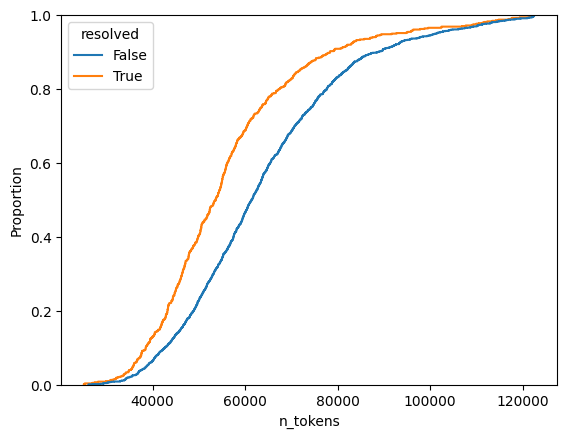

#total=2092
#selected=2092


,count,mean,std,min,25%,50%,75%,max
resolved,,,,,,,,
False,1458.0,64037.419067,18399.644217,26145.0,50993.00,61399.0,74225.5,122586.0
True,634.0,56543.324921,17421.519575,25152.0,44872.25,53631.0,63478.5,122078.0


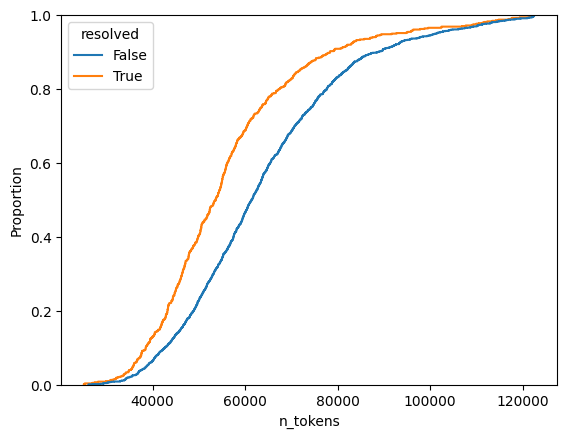

In [27]:
# ecdf of n_tokens
import matplotlib.pyplot as plt
import seaborn as sns

display(df.groupby(['resolved'])['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df, hue='resolved')
plt.show()

print(f'#total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'#selected={len(df_selected)}')
display(df_selected.groupby(['resolved'])['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df_selected, hue='resolved')
plt.show()

In [19]:
df_selected[~df_selected['resolved']]['n_tokens'].describe()

count       139.000000
mean      44511.194245
std       22726.616474
min        6010.000000
25%       28855.000000
50%       39218.000000
75%       54791.500000
max      127018.000000
Name: n_tokens, dtype: float64

In [28]:
df_selected['resolved'].value_counts()

resolved
False    1458
True      634
Name: count, dtype: int64

In [27]:
df_selected.groupby(['resolved'])['n_tokens'].describe()

,count,mean,std,min,25%,50%,75%,max
resolved,,,,,,,,
False,1458.0,64037.419067,18399.644217,26145.0,50993.00,61399.0,74225.5,122586.0
True,634.0,56543.324921,17421.519575,25152.0,44872.25,53631.0,63478.5,122078.0


In [29]:
def _normalize_to_sft_format(messages):
    """Convert messages to SWE-Gym/OpenHands-SFT-Trajectories format.

    Target: each message has only 'role' (str) and 'content' (str).
    """
    normalized = []
    for msg in messages:
        content = msg.get('content', '') or ''
        if isinstance(content, list):
            content = '\n'.join(
                part['text'] for part in content if part.get('type') == 'text'
            )
        normalized.append({'role': msg['role'], 'content': content})
    return normalized


df_selected = df_selected.copy()
df_selected['nonfncall_messages'] = df_selected['nonfncall_messages'].apply(_normalize_to_sft_format)
print('Normalized messages to SFT format (role + content strings only)')

Normalized messages to SFT format (role + content strings only)


# Save Resolved Messages for SFT

In [30]:

save_dir = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft"
# save_dir = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/sft"

if os.path.exists(save_dir):
    print(f'{save_dir} already exists, skipping saving.')
else:
    os.makedirs(save_dir, exist_ok=True)

df_selected[df_selected['resolved']][['nonfncall_messages']].rename(
    columns={'nonfncall_messages': 'messages'}
).to_json(
    os.path.join(
        save_dir,
        f'policy_traj_128k_swegym_resolved_{df_selected["resolved"].value_counts()[True]}i.jsonl',
    ),
    lines=True,
    orient='records',
)

df_selected[['nonfncall_messages']].rename(
    columns={'nonfncall_messages': 'messages'}
).to_json(
    os.path.join(
        save_dir,
        f'policy_traj_128k_swegym_all_{len(df_selected)}i.jsonl',
    ),
    lines=True,
    orient='records',
)

/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft already exists, skipping saving.
